In [1]:
import sys
sys.path.append("/home/mariacst/exoplanets/exoplanets/python")
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as colors
from matplotlib.offsetbox import AnchoredText
%matplotlib inline
from _corner import corner
import pickle
from scipy.stats import gaussian_kde, binned_statistic
from scipy.interpolate import UnivariateSpline, griddata
from scipy.optimize import minimize

from matplotlib import rc
rc('font', family='times new roman', size=18.)

In [2]:
#filepath = "/hdfs/local/mariacst/exoplanets/results/multinest/onlySigmaT/power_law/
filepath ="/home/mariacst/exoplanets/debug/multinest/power_law/out/"
rank = 1; gamma=1.5; sigma=0.1
_file    = filepath + "%i/T650_multinest_N100_sigma%.1f_gamma%.1f_rs5.0_v%ipost_equal_weights.dat"%(rank, sigma, gamma, rank)
samples1 = np.genfromtxt(_file, unpack=True)

gamma=0.5
_file    = filepath + "T650_multinest_N100_sigma%.1f_gamma%.1f_rs5.0_v%ipost_equal_weights.dat"%(sigma, gamma, rank)
samples2 = np.genfromtxt(_file, unpack=True)

NameError: name 'sigma' is not defined

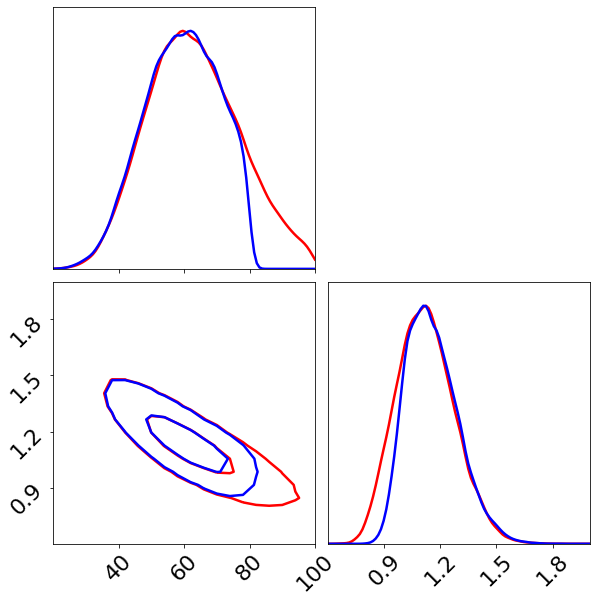

In [19]:
smooth=1.

fig, axes = corner(np.array([samples1[0], samples1[1]]).T, 
                   levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   range=((20, 100), (0.6, 2.)),
                   plot_density=False, fill_contours=False, smooth=smooth, color="red",)
# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 3], np.array([samples1[0], samples1[1]])):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="red", lw=2.5)   

    
corner(np.array([samples2[0], samples2[1]]).T, 
                   levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   range=((20, 100), (0.6, 2.)),
                   plot_density=False, fill_contours=False, smooth=smooth, color="blue", fig=fig)

for axidx, samps in zip([0, 3], np.array([samples2[0], samples2[1]])):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="blue", lw=2.5) 

In [26]:
import utils_plots_power_law
import imp
imp.reload(utils_plots_power_law)
from utils_plots_power_law import grid_FSE

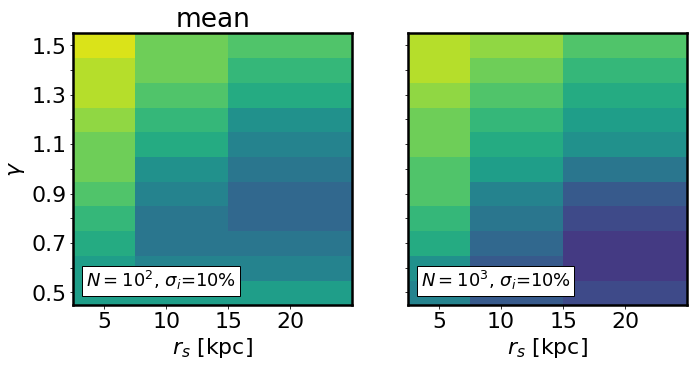

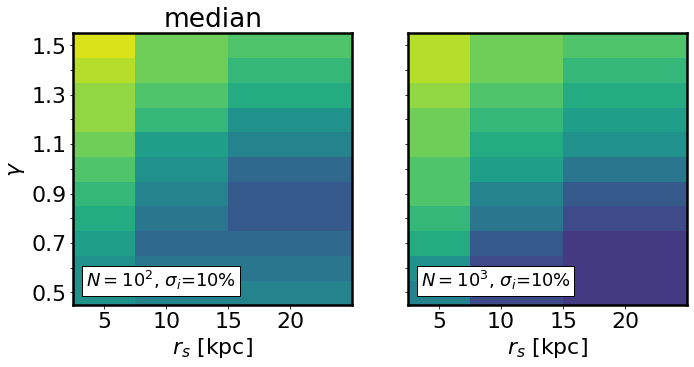

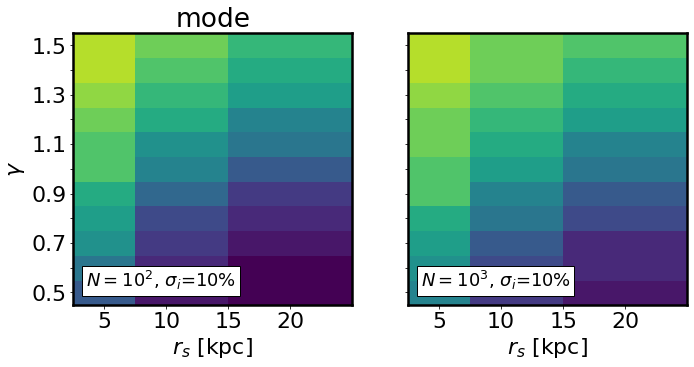

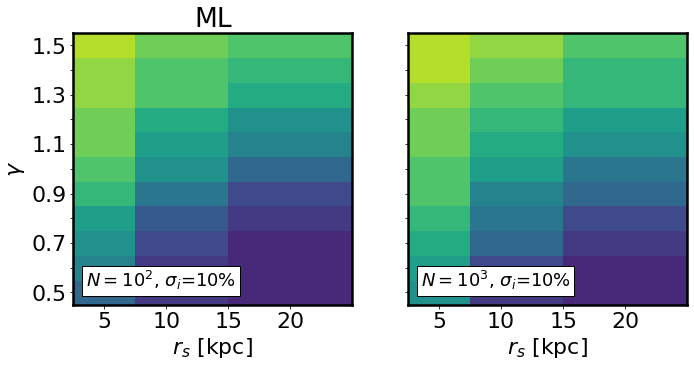

In [40]:
path = "/home/mariacst/exoplanets/results/power_law/onlySigmaT/"

for pe in ["mean", "median", "mode", "ML"]:
    fig, ax = plt.subplots(1, 2, figsize=(11, 5))
    grid_FSE(path, 100, 0.1, "T650_multinest", ax[0], pe, ylabel=True, xlabel=True)
    grid_FSE(path, 1000, 0.1, "T650_multinest", ax[1], pe, ylabel=False, xlabel=True)
    ax[0].set_title(pe)

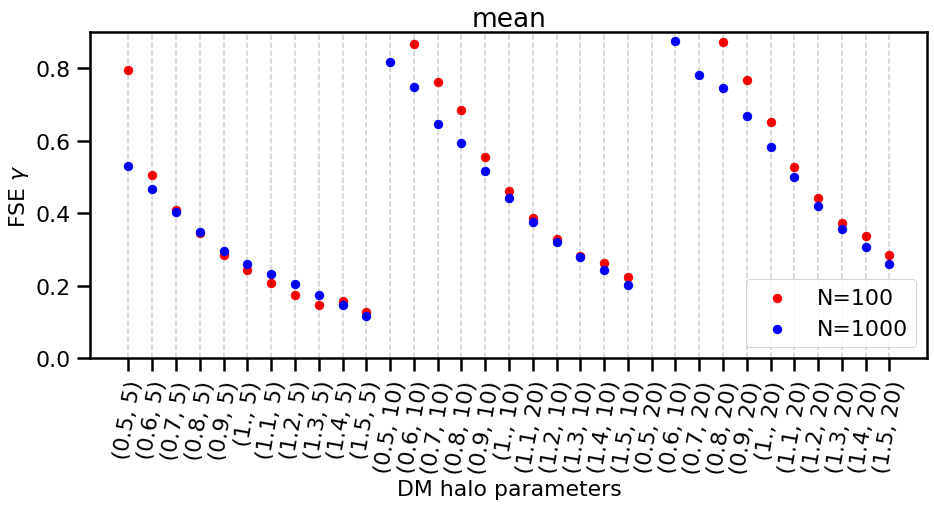

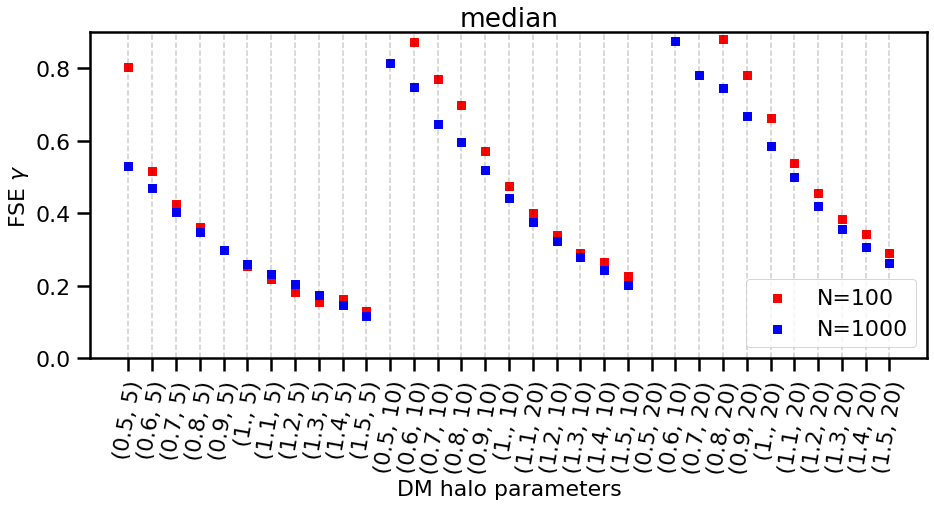

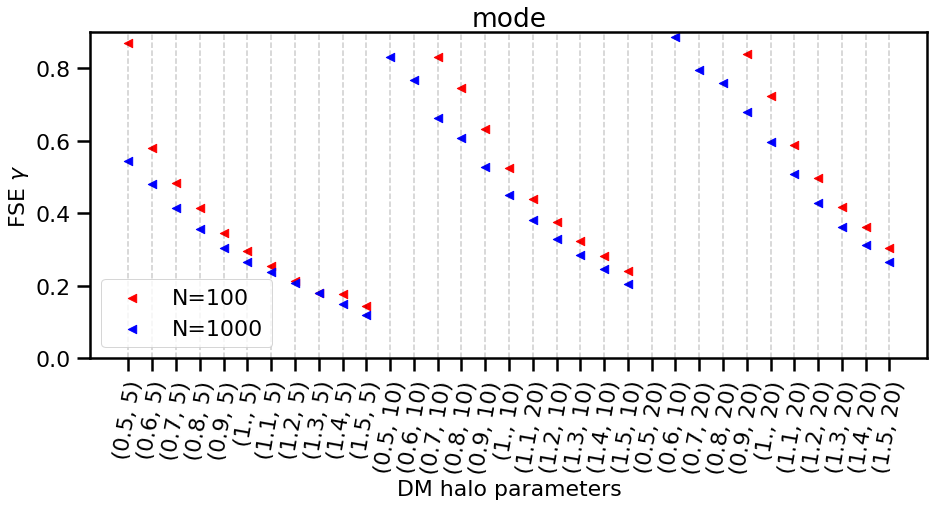

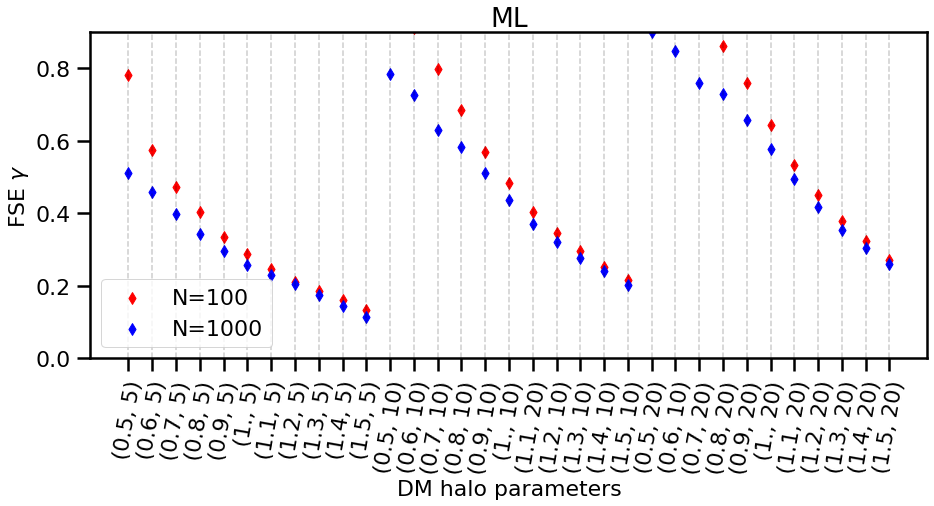

In [7]:
import imp
import utils_plots_power_law
imp.reload(utils_plots_power_law)

from utils_plots_power_law import FSE_f_gamma_rs


#IMPORTANT CHANGE UTILS_PLOTS_POWR_LAW INPUT STAT FILE!!!

path = "/home/mariacst/exoplanets/results/power_law/onlySigmaT/"

nBDs = [100, 1000]
sigma = 0.1

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]
x     = np.linspace(0, 1, 33)

PE     = ["mean", "median", "mode", "ML"]
color  = ["red", "blue"]
marker = ["o", "s", "<", "d"]

j=0
for pe in PE:   
    fig, ax = plt.subplots(1, 1, figsize=(15, 6))    
    i=0
    for N in nBDs:
        xi, yi, zi = FSE_f_gamma_rs(path, N, sigma, "T650_multinest", PE=pe)    
        ax.scatter(x, np.ravel(zi), color=color[i], marker=marker[j], label="N=%i"%N, s=70.)
        i+=1
    j+=1
    
    for axis in ['top','bottom','left','right']:                                    
        ax.spines[axis].set_linewidth(2.5) 
    ax.tick_params(which='major',direction="out",width=2.5,length=13,right=False,top=False,pad=7)
    
    for i in x:
        ax.axvline(i, ls="--", alpha=0.2, color="k")

    ax.legend()
    ax.set_xticks(x)    

    ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', 
                        '(1., 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                       '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', 
                        '(1., 10)', '(1.1, 20)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)', 
                        '(0.5, 20)', '(0.6, 10)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', 
                        '(1., 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', '(1.5, 20)', 
                       ], 
                   rotation=80);

    ax.set_ylim(0, 1.)
    ax.set_ylabel(r"FSE $\gamma$"); ax.set_xlabel("DM halo parameters")
    ax.set_title(pe)
    ax.set_ylim(0., 0.9)
    

#FSE_mean_100  = [0.597, 0.589, np.nan, np.nan, np.nan, np.nan, np.nan, 0.246, 0.208, 0.160, 0.115]
#FSE_mean_1000 = [0.731, 0.661, np.nan, np.nan, np.nan, np.nan, np.nan, 0.289, 0.246, 0.201, 0.154] 

#ax.scatter(x[:len(FSE_mean_100)], FSE_mean_100, color="red", marker="d")
#ax.scatter(x[:len(FSE_mean_1000)], FSE_mean_1000, color="blue", marker="d")

#fig.savefig(ex + "_FSE_gamma.png", bbox_inches="tight")

In [60]:
import utils_plots_power_law
import imp
imp.reload(utils_plots_power_law)
from utils_plots_power_law import grid_coverage

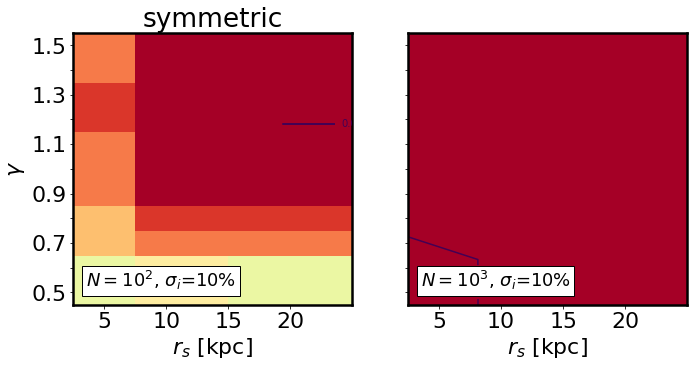

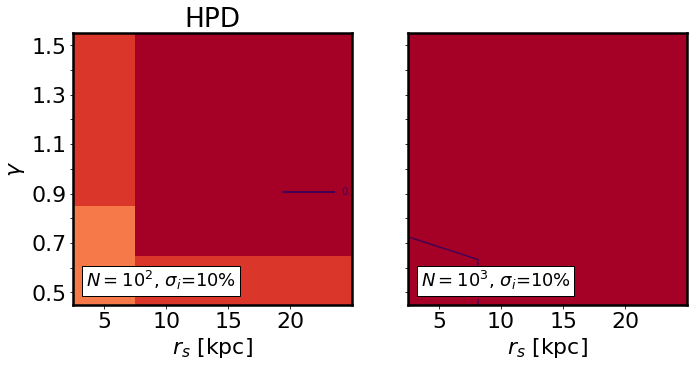

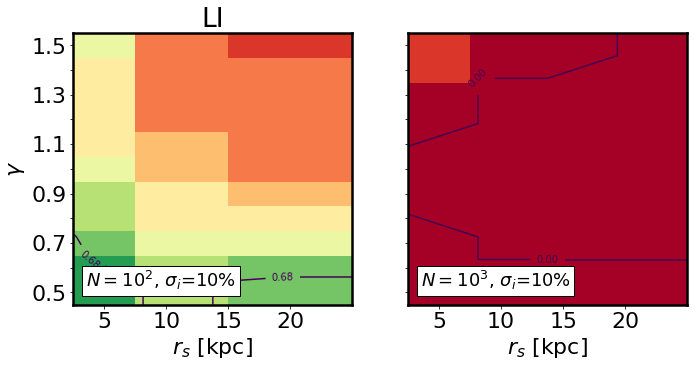

In [62]:
path = "/home/mariacst/exoplanets/results/power_law/onlySigmaT/"

for pe in ["symmetric", "HPD", "LI"]:
    fig, ax = plt.subplots(1, 2, figsize=(11, 5))
    grid_coverage(path, 100, 0.1, "T650_multinest", ax[0], pe, ylabel=True, xlabel=True)
    grid_coverage(path, 1000, 0.1, "T650_multinest", ax[1], pe, ylabel=False, xlabel=True)
    ax[0].set_title(pe)

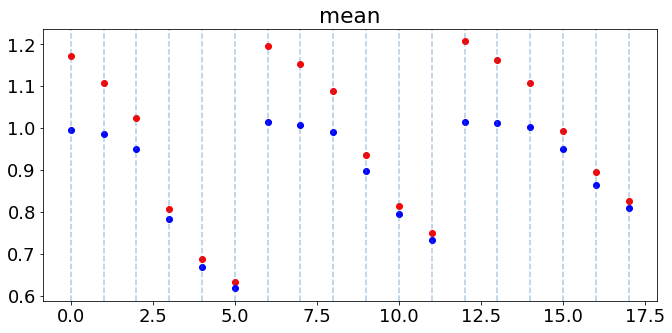

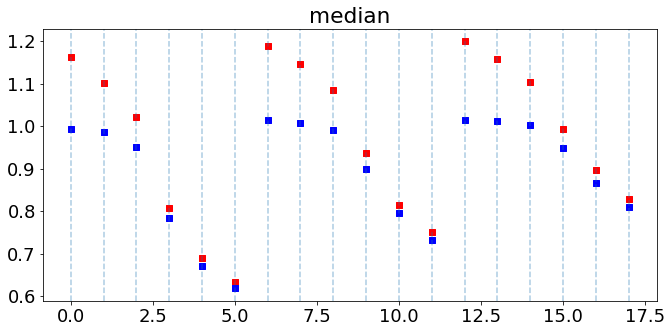

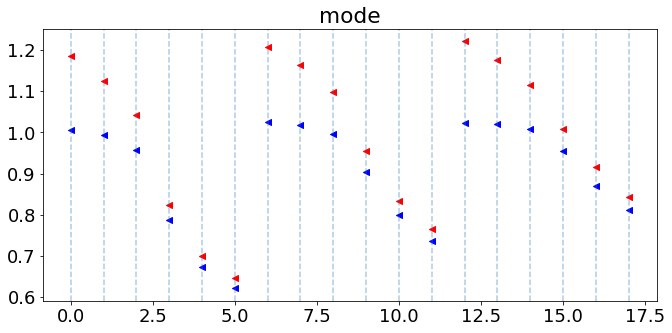

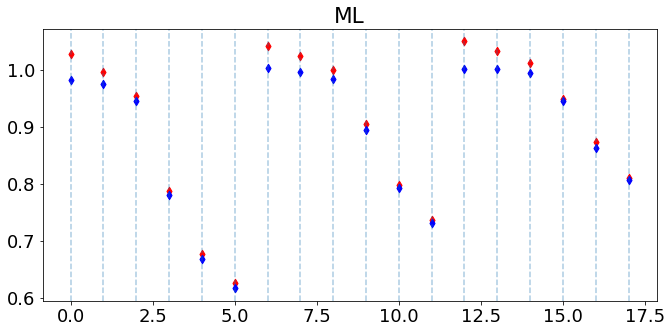

In [6]:
path = "/home/mariacst/exoplanets/results/power_law/sigma/"

nBDs  = [100, 1000]
sigma = [0.3]

gamma = [0.5, 0.6, 0.8, 1.2, 1.4, 1.5]
rs    = [5, 10, 20]

PE     = ["mean", "median", "mode", "ML"]
color  = ["red", "blue"]
marker = ["o", "s", "<", "d"]

x_axis = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

i=0
for pe in PE:   
    fig, ax = plt.subplots(1, 1, figsize=(11, 5)) 
    ax.set_title(pe)
    for s in sigma:
        for n in nBDs:
            x=0
            if n<200:
                color="red"
            else:
                color="blue"
            for _rs in rs:
                for _g in gamma:
                    data = np.genfromtxt(path + "statistics_T650_multinest" +           
                                 ("_N%i_sigma%.1f_gamma%.1frs%.1f_1_200_final"%(n, s, _g, _rs)), unpack=True)  
                    if pe=="median":                                                       
                        _pe = data[1]                                                       
                    elif pe=="mode":                                                       
                        _pe = data[4]                                                       
                    elif pe=="mean":                                                       
                        _pe = data[0]                                                       
                    elif pe=="ML":                                                         
                        _pe = data[7]                                                       
                    else:                                                                  
                        sys.exit("Point estimate not implemented!") 
                    rank=len(data[0])
                    FSE=np.sqrt(1/rank*np.sum(np.power(_pe - _g, 2)))/_g                     
                    ax.scatter(x, FSE, color=color, marker=marker[i])#, label="N=%i"%n)
                    ax.axvline(x, ls="--", alpha=0.2)
                    x+=1
                    #print(n, _g, _rs)
    i+=1
    #ax.legend()
    #ax.set_xticks(x_axis) 
    #ax.set_xticklabels(['(0.5, 5)', '(0.5, 5)', '(1.4, 5)', '(1.5, 5)', 
    #                    '(0.5, 10)', '(0.6, 10)', '(1.4, 10)', '(1.5, 10)',
    #                    '(0.5, 20)', '(0.6, 20)', '(1.4, 20)', '(1.5, 20)'
    #                   ], rotation=80);


In [46]:
path = "/home/mariacst/exoplanets/results/power_law/sigma/"

nBDs = [100, 1000]
sigma = [0.3]

gamma = [0.5, 0.6, 0.8,1.2, 1.4, 1.5]
rs    = [5, 20]

PE     = ["mean", "median", "mode", "ML"]
color  = ["red", "blue"]
marker = ["o", "s", "<", "d"]

x_axis = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]#, 12, 13, 14, 15, 16, 17]


def plot_FSE_pe(path, v, pe, marker, fig=None, ax=None):

    if not fig:
        fig, ax = plt.subplots(1, 1, figsize=(11, 5)) 
    ax.set_title(pe)
    for s in sigma:
        for n in nBDs:
            x=0
            if n<200:
                color="red"
            else:
                color="blue"
            for _rs in rs:
                for _g in gamma:
                    try:
                        data = np.genfromtxt(path + "statistics_T650_multinest" +           
                                 ("_N%i_sigma%.1f_gamma%.1frs%.1f_1_200_"%(n, s, _g, _rs)) + v, unpack=True) 
                    except:
                        data = np.genfromtxt(path + "statistics_T650_multinest" +           
                                 ("_N%i_sigma%.1f_gamma%.1frs%.1f_1_200_"%(n, s, _g, _rs)) + v, unpack=True)  
                    if pe=="median":                                                       
                        _pe = data[1]                                                       
                    elif pe=="mode":                                                       
                        _pe = data[4]                                                       
                    elif pe=="mean":                                                       
                        _pe = data[0]                                                       
                    elif pe=="ML":                                                         
                        _pe = data[7]                                                       
                    else:                                                                  
                        sys.exit("Point estimate not implemented!") 
                    rank=len(data[0])
                    FSE=np.sqrt(1/rank*np.sum(np.power(_pe - _g, 2)))/_g                     
                    ax.scatter(x, FSE, color=color, marker=marker)#, label="N=%i"%n)
                    ax.axvline(x, ls="--", alpha=0.2)
                    x+=1
    ax.set_xticks(x_axis) 
    #ax.set_xticklabels(['(1.2, 5)', '(1.4, 5)', '(1.5, 5)',
    #                    '(1.2, 20)', '(1.4, 20)', '(1.5, 20)'
    #                   ], rotation=80);
    ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.8, 5)', '(1.2, 5)', '(1.4, 5)', '(1.5, 5)',
                        #'(0.5, 10)', '(0.6, 10)', '(0.8, 10)', '(1.2, 10)', '(1.4, 10)', '(1.5, 10)',
                        '(0.5, 20)', '(0.6, 20)', '(0.8, 20)', '(1.2, 20)', '(1.4, 20)', '(1.5, 20)'
                       ], rotation=80);
    return fig, ax

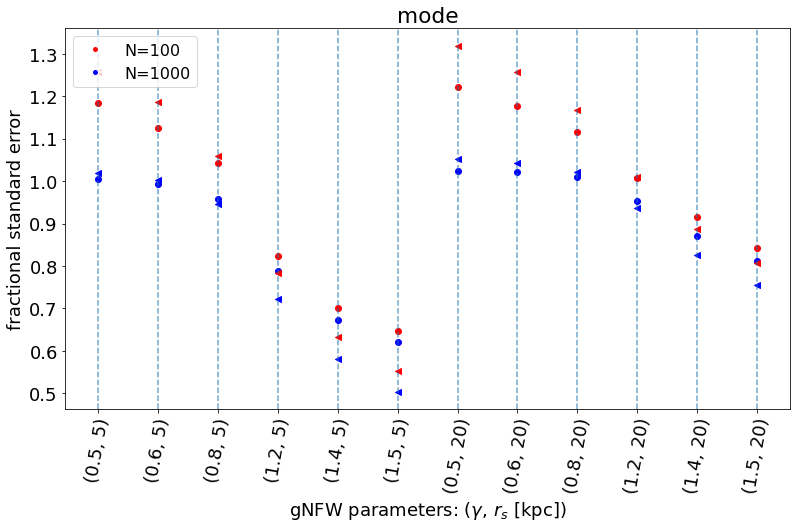

In [47]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(13, 7))

PE = ["mode"]#, "mean", "median", "ML"]
for pe in PE:
    fig, ax = plot_FSE_pe(path, "final", pe, "o", fig, ax)
    plot_FSE_pe(path, "final_non_linear", pe, "<", fig, ax)
    #plot_FSE_pe(path, "final_non_linear_wider", pe, "s", fig, ax)
    
    props = dict(boxstyle='round', facecolor='grey', alpha=0.2)
    #ax.text(0.5, 0.08, r"$\sigma_T=10\%$ $\sigma_{\rm mass}=\sigma_{\rm radius}=\sigma_{\rm age}=30\%$", 
    #        transform=ax.transAxes, fontsize=18, bbox=props, verticalalignment='top')
    
    legend_elements = [#Line2D([0], [0], marker='o', color='w', markerfacecolor='k', label='Linear error propag.'),
                       #Line2D([0], [0], marker='<', color='w', markerfacecolor='k', label='Non-linear error propag.'),
                       Line2D([0], [0], marker='o', color='w', markerfacecolor='r', label='N=100'),
                       Line2D([0], [0], marker='o', color='w', markerfacecolor='b', label='N=1000')
                       ]

    ax.legend(handles=legend_elements, loc='upper left', fontsize=16)
    ax.set_ylabel("fractional standard error")
    ax.set_xlabel(r"gNFW parameters: ($\gamma$, $r_s$ [kpc])")
    
    #fig.savefig("FSE_MAP_sigma0.1.pdf", bbox_inches="tight")